In [4]:
import importlib

from mysklearn.mypytable import MyPyTable 
import mysklearn.myutils
importlib.reload(mysklearn.myutils)

from mysklearn import myutils
from mysklearn.myclassifiers import MySimpleLinearRegressionClassifier
from mysklearn.myclassifiers import MyKNeighborsClassifier
from mysklearn.myclassifiers import MyNaiveBayesClassifier
from mysklearn.myclassifiers import MyDecisionTreeClassifier
from mysklearn.myclassifiers import MyDummyClassifier
from mysklearn.myclassifiers import MyRandomForestsClassifier
import mysklearn.myevaluation as myEval

import matplotlib.pyplot as plt
# All teams in the NBA order alphabetically (will be used at the end of the report)
alphabet_teams = ['Atlanta Hawks', 'Boston Celtics', 'Brooklyn Nets', 'Charlotte Hornets', 'Chicago Bulls',
        'Cleveland Cavaliers', 'Dallas Mavericks', 'Denver Nuggets', 'Detroit Pistons', 'Golden State Warriors', 'Houston Rockets', 'Indiana Pacers',
        'Los Angeles Clippers', 'Los Angeles Lakers', 'Memphis Grizzlies', 'Miami Heat', 'Milwaukee Bucks', 'Minnesota Timberwolves',
        'New Orleans Pelicans', 'New York Knicks', 'Oklahoma City Thunder', 'Orlando Magic', 'Philadelphia 76ers',
        'Phoenix Suns', 'Portland Trailblazers', 'Sacramento Kings', 'San Antonio Spurs', 'Toronto Raptors', 'Utah Jazz', 'Washington Wizards']


# Project Report
#### By: Joe Mock and James Cross

In this project, we decided to look at data concerning the National Basketball Association **(NBA)**. All data used in this project was provided by *basketball-reference.com*.
    
For some context, every year, every team in the NBA plays 82 games in what is called the **"Regular Season."** Based on win/loss ratios throughout the *Regular Season* and a few other factors, teams will be ranked and play in **"Playoff"** games, where they will be put into a bracket and compete to win the championship.
    
We will primarily look at win/loss ratios and points scored throughout the season to predict whether teams will make the **Playoffs**.
    
The data that we have pulled was put into three files in the /data/input section of this project. *"season_data.txt"* and *"season_stats.txt"* are the primary files used for training our classifiers in this project. The current NBA season is still going on and is about a quarter of the way through, so we also compiled current season statistics for each team in *"testing_stats.txt"* to classify which teams will make the Playoffs this year for fun.
    
The two primary input files are organized by team and season, where each row/instance correlates to a specific team's average stats throughout a specific NBA season</p>

## Dataset Introduction

Basketball Reference does not provide a holistic view for the data that we wish to look at, so we will have to look at two different files to clean and join for relevant data. By creating a unique id column in each file, we can join each season as it correlates to itself. We pulled data in a parralel manner where each row/instance in each file correlates to the same row/instance in the other file.
    
For example, Row 1 in *season_data.txt* and Row 1 in *season_stats.txt* both hold statistics for the **Atlanta Hawks** (NBA team) in the **2024-25 Season**

There is a number of statistics in both files, but the primary ones we will look at are W, 2P, 3P, 2PA, 3PA.

**Key**
- 2P : Average number of 2-point valued scores a team makes throughout a season
- 3P : Average number of 3-point valued scores a team makes throughout a season
- 2PA : Average number of 2-point valued scores a team allows throughout a season
- 3PA : Average number of 3-point valued scores a team allows throughout a season
- W : Amount of Wins a team obtains throughout a season

In a holistic view, the NBA normally has two scoring options (2-points or 3-points). So the average amount of 2P and 3P combined will correlate to the average amount of points a team scores throughout a season which can also be understood by the average amount of points scored per game throughout a season. The opposing team also has opportunites to score in the same way, so 2PA and 3PA combined will be the total average points a team allows throughout a season (how many points an opposing team normally scores). Since games are decided by which team scores more points, these are the primary statistics that we will consider.

## Dataset Cleaning

In [5]:
# We will first load our datasets from .txt files pulled from basketball-reference.com
# This includes data for every season played by every team in the NBA
nba_data = MyPyTable().load_from_file("data/input/season_data.txt")
nba_stats = MyPyTable().load_from_file("data/input/season_stats.txt")
nba_data.drop_column(['Team','W','L','W/L%','Finish','SRS','','Pace','Rel Pace','Rel ORtg','Rel DRtg','Coaches','Top WS'])
nba_stats.drop_column([''])
nba_data.add_keyid_column()
nba_stats.add_keyid_column()
nba_all_data = nba_data.perform_full_outer_join(nba_stats, ["id", "Season", "Lg"])
myutils.label_playoff(nba_all_data)
nba_all_data.remove_rows_with_missing_values()

nba_all_data.save_to_file("data/output/nba_output.txt")

By cleaning this data we have a combined file containing all the necessary information needed to run our classifiers. For some further context and understanding, *season_stats.txt* contained all the statistical values that we wanted to consider, whereas *season_data.txt* contained a column determining whether the specified team made the playoffs in that year (which is needed for testing our classifier).

## Data Visualization / EDA

Text(0, 0.5, 'Number of teams')

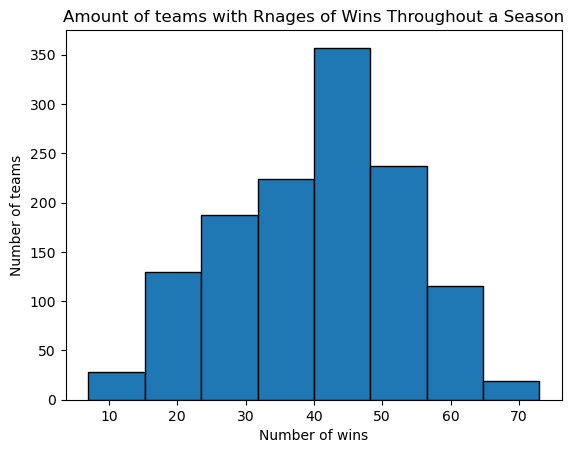

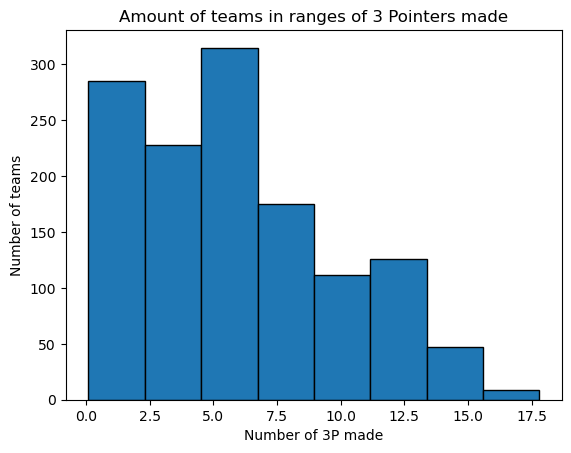

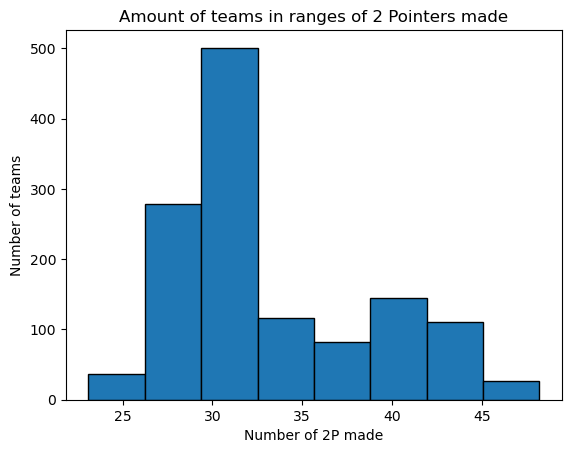

In [6]:
# Things to consider: Win/Loss, Points
plt.figure()
xs = nba_all_data.get_column("W")
plt.hist(xs, bins=8, edgecolor='black')
plt.title(f"Amount of teams with Rnages of Wins Throughout a Season")
plt.xlabel("Number of wins")
plt.ylabel("Number of teams")

plt.figure()
xs = nba_all_data.get_column("3P")
plt.hist(xs, bins=8, edgecolor='black')
plt.title("Amount of teams in ranges of 3 Pointers made")
plt.xlabel("Number of 3P made")
plt.ylabel("Number of teams")

plt.figure()
xs = nba_all_data.get_column("2P")
plt.hist(xs, bins=8, edgecolor='black')
plt.title("Amount of teams in ranges of 2 Pointers made")
plt.xlabel("Number of 2P made")
plt.ylabel("Number of teams")


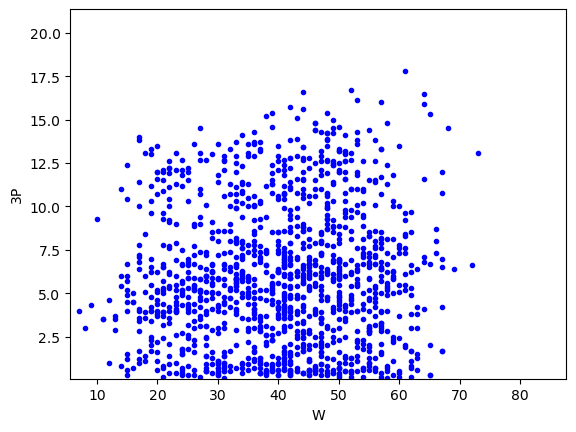

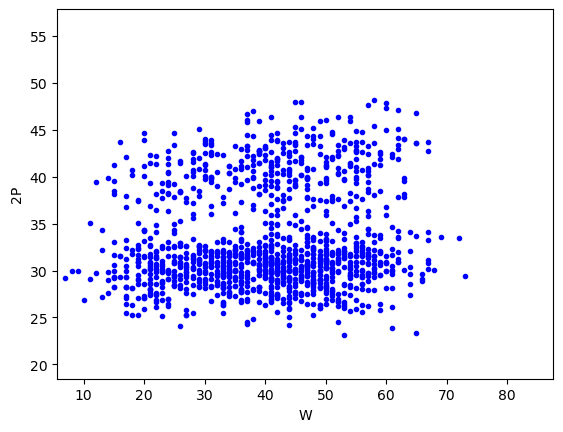

In [7]:
myutils.get_scatter("W", "3P", nba_all_data)
myutils.get_scatter("W", "2P", nba_all_data)


The above **Histograms** were created with the intention of getting a sense of the distribution of teams falling into different ranges of statistical categories. From the Histograms, we can see that the number of wins teams obtain is fairly Normal, and the amount of 2P and 3P scored is often skewed, with fewer teams on the higher end.

The **Scatter Plots** were created to get a sense of the data to see whether teams win more games based on the amount of 2P and 3P they score. We can see that there is a very weak relationship here which may be some reasoning towards our results / accuracy in our classifiers later in this report.

## Classifier Training

Now that we have all the data loaded and cleaned, we can continue by building, training, and evaluating the classifiers that we have built throughout this semester.

We will look at every classifier that we have developed throughout the semester to determine which one provides the most accurate result.

### Linear Regression

In [8]:
# Goal is to classify whether a team will make the playoffs
# Which factor is best for classifying this for linear regression?

# We can use linear regression to see how well our classifiers will work
# We can predict the amount of games teams will win based off how many points they score
# 2P means a 2P 
X = myutils.get_instances(nba_all_data, ["2P", "3P", "2PA", "3PA"])
y = nba_all_data.get_column("W")
X_train, X_test, y_train, y_test = myEval.train_test_split(X, y) 

linearClass = MySimpleLinearRegressionClassifier(discretizer=None)
linearClass.fit(X_train, y_train)

pred = linearClass.predict(X_test)

# Convert to integers since teams cannot have "partial" wins
pred = [int(x) for x in pred[0]]
actual = [int(x) for x in y_test]
avg_diff = myutils.get_prediction_difference(actual, pred)
pred = myutils.assert_made_playoffs(pred)
actual = myutils.assert_made_playoffs(actual)
myutils.nba_class_performance_view(actual, pred)
print("Average difference in won games prediction was off by:", avg_diff, "games")

Playoffs made accuracy
Actual on the left, predicted on the top
+-----+-------+------+
|     |   Yes |   No |
+=====+=======+======+
| Yes |     0 |  181 |
+-----+-------+------+
| No  |     0 |  248 |
+-----+-------+------+
Accuracy: 0.58
Recall: 1.0
F1 Score: 0.73
Average difference in won games prediction was off by: 10.895104895104895 games


With linear regression classification, we can easily predict how many games each team will win in a given season based on **Points Scored**. The larger issue with this type of classification in our dataset is that we are using the general rule that a team must win 45 or more games to make the playoffs. This can fluctuate and be different depending on the season. This can also be skewed for teams on the fringe, because the classifier was only off by a few games on average, but if teams are close to making the playoffs (or close to missing them), this small difference can display largely different results based on the playoff rule that we are using.

We can see that our classifier never predicted a team to win 45 or more games so did not provide nearly enough accurate results that we wanted.

### kNN Classification

In [9]:
# Training and testing example implementation
mykNNClass = MyKNeighborsClassifier()
X = myutils.get_instances(nba_all_data, ["2P", "3P", "2PA", "3PA"])
y = nba_all_data.get_column("Playoffs")
X_train, X_test, y_train, y_test = myEval.train_test_split(X, y) 
mykNNClass.fit(X_train, y_train)
pred = mykNNClass.predict(X_test)
accuracy = myEval.accuracy_score(y_test, pred)

# All above code is compiled into a cross-validation prediction using k = 10 folds
myutils.cross_val_predict(X, y, 10, mykNNClass)

Playoffs Made Classifier Evaluation
Actual on the left, predicted on the top
+-----+-------+------+
|     |   Yes |   No |
+=====+=======+======+
| Yes |   500 |  233 |
+-----+-------+------+
| No  |   235 |  329 |
+-----+-------+------+
Predictive Accuracy, Precision, Recall, F1 Measure
10 Fold Cross Validation
Accuracy = 0.64 error rate = 0.36
Precision = 0.64 error rate = 0.36
Recall = 0.65 error rate = 0.35
F1 Score = 0.64 error rate = 0.36


### Naive Bayes Classification

In [10]:
# Naive Bayes Training and Testing example implementation
myNaive = MyNaiveBayesClassifier()
X = myutils.get_instances(nba_all_data, ["W", "2P", "3P", "2PA", "3PA"])
y = nba_all_data.get_column("Playoffs")
X_train, X_test, y_train, y_test = myEval.train_test_split(X, y) 
myNaive.fit(X_train, y_train)
pred = myNaive.predict(X_test)
accuracy = myEval.accuracy_score(y_test, pred)

# All above code is compiled into a cross validation prediction function and evaluates performance
myutils.cross_val_predict(X, y, 10, myNaive)

Playoffs Made Classifier Evaluation
Actual on the left, predicted on the top
+-----+-------+------+
|     |   Yes |   No |
+=====+=======+======+
| Yes |   403 |  330 |
+-----+-------+------+
| No  |   114 |  450 |
+-----+-------+------+
Predictive Accuracy, Precision, Recall, F1 Measure
10 Fold Cross Validation
Accuracy = 0.66 error rate = 0.34
Precision = 0.69 error rate = 0.31
Recall = 0.67 error rate = 0.33
F1 Score = 0.66 error rate = 0.34


### TDIDT Classification

In [11]:
# Since our TDIDT only works for categorical data, we will "bin" our continuous data
# For every column, the lower third will be labeled "bad", the middle third "average"
# and the high third "good"
myTDIDT2 = MyDecisionTreeClassifier()
X = myutils.get_instances(nba_all_data, ["2P", "3P", "2PA", "3PA"])
X = myutils.bin_nba_data(X)
y = nba_all_data.get_column("Playoffs")
X_train, X_test, y_train, y_test = myEval.train_test_split(X, y)
myTDIDT2.fit(X_train, y_train)
pred = myTDIDT2.predict(X_test)
#print(pred)
myutils.nba_class_performance_view(y_test, pred)

# Example Visualization, Can view in project folder
myTDIDT2.visualize_tree("playoff_pred", "playoff_pred", attribute_names=["2P", "3P", "2PA", "3PA"])

Playoffs made accuracy
Actual on the left, predicted on the top
+-----+-------+------+
|     |   Yes |   No |
+=====+=======+======+
| Yes |   236 |   20 |
+-----+-------+------+
| No  |   125 |   48 |
+-----+-------+------+
Accuracy: 0.66
Recall: 0.92
F1 Score: 0.76
Decision tree visualization saved to playoff_pred.pdf and playoff_pred.dot


### Random Forests Classification

In [15]:
# Expecting RF to produce highest accuracy so will be taking into account two different
# sets of attributes in this case
myRF = MyRandomForestsClassifier(n_trees=3)
X = myutils.get_instances(nba_all_data, ["2P", "3P", "2PA", "3PA"])
X = myutils.bin_nba_data(X)
y = nba_all_data.get_column("Playoffs")
X_train, X_test, y_train, y_test = myEval.train_test_split(X, y)
myRF.fit(X, y)
predicted = myRF.predict(X_test)

actual = y_test
myutils.nba_class_performance_view(actual, predicted)
print()
otherRF = MyRandomForestsClassifier(n_trees=3)
X = myutils.get_instances(nba_all_data, ["W", "2P", "3P", "2PA", "3PA"])
X = myutils.bin_nba_data(X)
y = nba_all_data.get_column("Playoffs")
X_train, X_test, y_train, y_test = myEval.train_test_split(X, y)
otherRF.fit(X, y)
predicted = otherRF.predict(X_test)

actual = y_test
myutils.nba_class_performance_view(actual, predicted)

Playoffs made accuracy
Actual on the left, predicted on the top
+-----+-------+------+
|     |   Yes |   No |
+=====+=======+======+
| Yes |   235 |   19 |
+-----+-------+------+
| No  |   125 |   50 |
+-----+-------+------+
Accuracy: 0.66
Recall: 0.29
F1 Score: 0.41

Playoffs made accuracy
Actual on the left, predicted on the top
+-----+-------+------+
|     |   Yes |   No |
+=====+=======+======+
| Yes |   243 |   14 |
+-----+-------+------+
| No  |    44 |  128 |
+-----+-------+------+
Accuracy: 0.86
Recall: 0.95
F1 Score: 0.89


Above, we ran through all of the classifiers and it is apparent by taking a quick look at the performance that our Random Forests and TDIDT algorithms were the most successful in prediction. For those classifiers, we chose the 33rd and 66th percentiles of each attribute to create the bins of *"bad"*, *"average*, and *"good"*.

### This Season Predictions
Since our Random Forests Classifier produces the most accurate results, we will use this. For fun we will predict which NBA teams will make the playoffs this season using the RF classifier we have just trained. We will not be able to test this right now, as the playoffs have not happened yet, but we will use the current average statistics for each NBA team.

The current NBA season (2025-26) started in October, so it is about a month in, and the average statistics represent how teams are currently performing through this portion of the season.s

In [16]:
this_season = MyPyTable().load_from_file("data/input/testing_stats.txt")

X_test = myutils.get_instances(this_season, ["W", "2P", "3P", "2PA", "3PA"])
X_test = myutils.bin_nba_data(X_test)
predicted = otherRF.predict(X_test)

for i, pred in enumerate(predicted):
    print("Team:", alphabet_teams[i], "Makes playoffs:", pred)

Team: Atlanta Hawks Makes playoffs: Yes
Team: Boston Celtics Makes playoffs: Yes
Team: Brooklyn Nets Makes playoffs: No
Team: Charlotte Hornets Makes playoffs: No
Team: Chicago Bulls Makes playoffs: No
Team: Cleveland Cavaliers Makes playoffs: Yes
Team: Dallas Mavericks Makes playoffs: No
Team: Denver Nuggets Makes playoffs: Yes
Team: Detroit Pistons Makes playoffs: Yes
Team: Golden State Warriors Makes playoffs: Yes
Team: Houston Rockets Makes playoffs: Yes
Team: Indiana Pacers Makes playoffs: Yes
Team: Los Angeles Clippers Makes playoffs: No
Team: Los Angeles Lakers Makes playoffs: Yes
Team: Memphis Grizzlies Makes playoffs: Yes
Team: Miami Heat Makes playoffs: No
Team: Milwaukee Bucks Makes playoffs: Yes
Team: Minnesota Timberwolves Makes playoffs: Yes
Team: New Orleans Pelicans Makes playoffs: No
Team: New York Knicks Makes playoffs: Yes
Team: Oklahoma City Thunder Makes playoffs: Yes
Team: Orlando Magic Makes playoffs: Yes
Team: Philadelphia 76ers Makes playoffs: Yes
Team: Phoenix

## Conclusion and Next Steps

It was apparent that after running the classifiers, our most successful one was the random forests, which produced the highest accuracy. This makes sense because it is usually the best option when classifying this. We ran this program many times because some functions, like random subsampling and bootstrapping, use random numbers, and these results usually held.

One of the things that we found very interesting is how drastically performance would improve when also looking at wins, rather than just at basic scoring statistics. Since NBA wins and losses are decided by how many points a team scores versus how many points the other teams score, we did not think that this would be the case. In the Random Forests classification, accuracy increased by more than 30% when also training on the number of Wins statistic (W).

In the future, we plan to improve this classifier by pulling more data from basketball-reference, for example, player data, as some seasons, teams will lose their best players due to injury or through player trade, which can drastically change overall team performance mid-season.

For the Decision Tree and Random Forests classification in particular, another improvement that we could do in place is to bin the data better. We only split the continuous data into thirds, which could overgeneralize the data. With more data analysis, there could be another way to define better bins for the data, or just more bins to generate more accurate classifications of each column within the training data, which would lead to more accurate and trustworthy decision rules.